# Skyvista API Reference

Skyvista provides a clean, composable API for 3D atmospheric data visualization.
The API is designed around the `Scene` class which acts as a container for
visualization specifications.

## Setup

First, let's import skyvista and set up PyVista for notebook rendering.

In [1]:
import skyvista as sv
import numpy as np
import xarray as xr
import pyvista as pv

from pathlib import Path
from IPython.display import display, Image

## Creating Sample Data

Let's create some sample datasets to demonstrate the API.

In [5]:
# Create sample gridded data
x = np.linspace(0, 10000, 50)
y = np.linspace(0, 10000, 50)
z = np.linspace(0, 5000, 25)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

# Temperature field with vertical gradient and a warm anomaly
THETA = (
    300
    + Z / 100
    + 10 * np.exp(-((X - 5000) ** 2 + (Y - 5000) ** 2 + (Z - 2500) ** 2) / 2000**2)
)

# Vertical velocity with updraft core
W = (
    5
    * np.exp(-((X - 5000) ** 2 + (Y - 5000) ** 2) / 1500**2)
    * np.exp(-((Z - 3000) ** 2) / 1000**2)
)

# Simple wind field
UC = np.ones_like(X) * 10  # Uniform eastward wind
VC = np.zeros_like(X)
WC = W.copy()

gridded_ds = xr.Dataset(
    {
        "THETA": (["x", "y", "z"], THETA),
        "W": (["x", "y", "z"], W),
        "UC": (["x", "y", "z"], UC),
        "VC": (["x", "y", "z"], VC),
        "WC": (["x", "y", "z"], WC),
    },
    coords={"x": x, "y": y, "z": z},
)

print(gridded_ds)

<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11


In [6]:
# Create sample trajectory data
n_trajectories = 20
n_times = 50

trajectory_ix = np.arange(n_trajectories)
times = np.arange(n_times)

# Trajectories spiraling upward
traj_x = np.zeros((n_trajectories, n_times))
traj_y = np.zeros((n_trajectories, n_times))
traj_z = np.zeros((n_trajectories, n_times))

for i in range(n_trajectories):
    # Start positions around center
    angle = 2 * np.pi * i / n_trajectories
    r0 = 1000 + 500 * np.random.rand()

    t = np.linspace(0, 4 * np.pi, n_times)
    r = r0 + t * 100  # Spiral outward

    traj_x[i, :] = 5000 + r * np.cos(angle + t * 0.5)
    traj_y[i, :] = 5000 + r * np.sin(angle + t * 0.5)
    traj_z[i, :] = 500 + t * 300  # Rise over time

# Altitude as scalar for coloring
altitude = traj_z.copy()

trajectory_ds = xr.Dataset(
    {
        "x": (["trajectory_ix", "time"], traj_x),
        "y": (["trajectory_ix", "time"], traj_y),
        "z": (["trajectory_ix", "time"], traj_z),
        "altitude": (["trajectory_ix", "time"], altitude),
    },
    coords={"trajectory_ix": trajectory_ix, "time": times},
)

print(trajectory_ds)

<xarray.Dataset> Size: 33kB
Dimensions:        (trajectory_ix: 20, time: 50)
Coordinates:
  * trajectory_ix  (trajectory_ix) int64 160B 0 1 2 3 4 5 ... 14 15 16 17 18 19
  * time           (time) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
Data variables:
    x              (trajectory_ix, time) float64 8kB 6.346e+03 ... 7.522e+03
    y              (trajectory_ix, time) float64 8kB 5e+03 ... 4.18e+03
    z              (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03
    altitude       (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03


## Quick Start

The fastest way to visualize data is using the convenience functions.

In [5]:
# Plot gridded data with isosurfaces
scene = sv.plot_gridded(
    gridded_ds,
    contours={"THETA": [305, 308]},
)

2026-03-19 22:26:16.617 (  38.811s) [    7F73F165C740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=:99.0


Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70d619e660_0&reconnect=auto" class="pyvi…

## Core Concepts

### Scene

The `Scene` class is the primary entry point. It accumulates visualization
specifications (VarSpecs) and handles rendering.

In [6]:
# Create a scene with custom settings
scene = sv.Scene(
    background="#f8f6f1",  # Background color
    title="Storm Simulation",
    show_grid=True,  # Show coordinate grid
)

print(f"Scene background: {scene.background}")
print(f"Show grid: {scene.show_grid}")

Scene background: #f8f6f1
Show grid: True


### VarSpecs

Each visualization type has a corresponding VarSpec class:

- `ContourSpec` - Isosurfaces
- `VolumeSpec` - Volume rendering  
- `VectorSpec` - Vector glyphs
- `SliceSpec` - 2D slices
- `TrajectorySpec` - Lagrangian trajectories

VarSpecs have two components:
- **Geometry** - What data to extract and how (varname, thresholds, etc.)
- **Appearance** - How to render it (opacity, color, cmap, etc.)

In [ ]:
# Create a contour spec using the factory function
contour_spec = sv.make_contour(
    "THETA",
    isosurfaces=[305, 308],
    opacity=0.7,
    color="blue",
)

print(f"Spec name: {contour_spec.name}")
print(
    f"Geometry: varname={contour_spec.geometry.varname},"
    f" isosurfaces={contour_spec.geometry.isosurfaces}"
)
print(
    f"Appearance: opacity={contour_spec.appearance.opacity},"
    f" color={contour_spec.appearance.color}"
)

Spec name: contour_THETA_iso305
Geometry: varname=THETA, isosurfaces=[305, 308]
Appearance: opacity=0.7, color=blue


## Factory Functions

Factory functions provide a convenient way to create VarSpecs with sensible defaults.

### make_contour

Creates isosurface meshes from scalar fields.

In [8]:
# Contour spec with various options
spec = sv.make_contour(
    "THETA",
    isosurfaces=[305, 308],
    opacity=0.7,
    color="blue",
)

# Use it in a scene
scene = sv.Scene()
scene.add(gridded_ds, spec)
scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70d44e9bd0_1&reconnect=auto" class="pyvi…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso305', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=ContourGeometry(varname='THETA', isosurfaces=[305, 308], scala

### make_slice

Creates 2D cross-sections through 3D data.

In [9]:
# Horizontal slice at z=2500
slice_spec = sv.make_slice(
    "THETA",
    dim="z",
    value=2500,
    cmap="RdBu_r",
)

scene = sv.Scene()
scene.add(gridded_ds, slice_spec)
scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70d330d090_2&reconnect=auto" class="pyvi…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, SliceSpec(name='slice_THETA_z', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=SliceGeometry(varname='THETA', slice_dim='z', slice_value=2500, slice_m

### make_vectors

Creates vector field visualization using glyphs.

In [ ]:
# Vector field
vector_spec = sv.make_vectors(
    "wind",
    u="UC",
    v="VC",
    w="WC",
    factor=50,  # Scale factor for arrow size
    # Tolerance is a simple way to control the density of arrows—
    # see the pyvista docs for the Mesh.glyph method for more on this
    tolerance=0.07,
)

scene = sv.Scene()
scene.add(gridded_ds, vector_spec)
scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc76f250_7&reconnect=auto" class="pyvi…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, VectorSpec(name='vector_wind', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=VectorGeometry(varname='wind', u_varname='UC', v_varname='VC', w_varname

### make_trajectory

Creates Lagrangian trajectory visualizations.

In [16]:
# Trajectory visualization
traj_spec = sv.make_trajectory(
    scalar="altitude",  # Color by altitude
    style="tube",
    cmap="viridis",
)

scene = sv.Scene()
scene.add(trajectory_ds, traj_spec)
scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc76f890_8&reconnect=auto" class="pyvi…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 33kB
Dimensions:        (trajectory_ix: 20, time: 50)
Coordinates:
  * trajectory_ix  (trajectory_ix) int64 160B 0 1 2 3 4 5 ... 14 15 16 17 18 19
  * time           (time) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
Data variables:
    x              (trajectory_ix, time) float64 8kB 6.139e+03 ... 7.37e+03
    y              (trajectory_ix, time) float64 8kB 5e+03 ... 4.23e+03
    z              (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03
    altitude       (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03, TrajectorySpec(name='trajectory_tube_altitude', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=TrajectoryGeometry(scalar='altitude', tube_radius=70, head_length_frac=10, head_radius_frac=2.5, tube_resolution=4, head_radial_resolution=30), _appearance=TrajectoryAppearance(color=None, opacity=1.0, cm

## Scene Methods

Scenes provide shorthand methods for adding visualizations.

In [17]:
# Build a scene using shorthand methods
scene = sv.Scene(background="#1a1a2e")

# Add contours
scene.add_contour(gridded_ds, "THETA", isosurfaces=[306], opacity=0.5, color="orange")
scene.add_contour(gridded_ds, "W", isosurfaces=[2], opacity=0.7, color="white")

# Add a slice
scene.add_slice(gridded_ds, "THETA", dim="y", value=5000, cmap="coolwarm")

scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc4a4910_9&reconnect=auto" class="pyvi…

Scene(background='#1a1a2e', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso306', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=ContourGeometry(varname='THETA', isosurfaces=[306], scalar=Non

### Method Chaining

All Scene methods return `self`, enabling fluent chaining.

In [18]:
# Fluent API with method chaining
scene = (
    sv.Scene(background="black")
    .add_contour(gridded_ds, "THETA", isosurfaces=[305], color="blue", opacity=0.5)
    .add_contour(gridded_ds, "THETA", isosurfaces=[308], color="red", opacity=0.5)
    .add_slice(gridded_ds, "W", dim="z", value=3000, cmap="RdBu_r")
)

scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc4a5950_10&reconnect=auto" class="pyv…

Scene(background='black', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso305', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=ContourGeometry(varname='THETA', isosurfaces=[305], scalar=None,

### Adding Multiple Contours

Use `add_contours()` with a dictionary for multiple variables.

In [20]:
scene = sv.Scene()

# Add multiple contours from a dictionary
scene.add_contours(
    gridded_ds,
    {
        "THETA": [305, 308],  # Simple form: variable -> isosurface values
        "W": {
            "isosurfaces": [2, 3],
            "color": "red",
            "opacity": 0.6,
        },  # Full form with options
    },
)

scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc4a6990_11&reconnect=auto" class="pyv…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso305', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=ContourGeometry(varname='THETA', isosurfaces=[305, 308], scala

## Combining Gridded Data and Trajectories

In [21]:
# Combined visualization
scene = (
    sv.Scene(background="#0f0f23")
    .add_contour(gridded_ds, "THETA", isosurfaces=[307], opacity=0.3, color="lightblue")
    .add_trajectories(trajectory_ds, scalar="altitude", cmap="plasma")
)

scene.show()

Widget(value='<iframe src="http://localhost:46471/index.html?ui=P_0x7f70bc4a7d90_12&reconnect=auto" class="pyv…

Scene(background='#0f0f23', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso307', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, _geometry=ContourGeometry(varname='THETA', isosurfaces=[307], scalar=Non

## Grid Builders

Skyvista automatically detects grid types and builds appropriate PyVista meshes.

In [24]:
# Check what grid type is detected
grid_type = sv.detect_grid_type(gridded_ds)
print(f"Detected grid type: {grid_type}")

# Get a grid builder
builder = sv.get_grid_builder(gridded_ds)
print(f"Builder class: {builder.__class__.__name__}")

Detected grid type: <skyvista.grids.RectilinearGridBuilder object at 0x7f70cbf1ad50>
Builder class: RectilinearGridBuilder


### Available Grid Builders

- `RectilinearGridBuilder` - Regular x/y/z grids
- `CurvilinearGridBuilder` - 2D/3D coordinate arrays
- `GeographicGridBuilder` - Lat/lon data on a sphere
- `SphericalGridBuilder` - Radar data (range/azimuth/elevation)

See `examples/coordinate_systems_demo.ipynb` for examples of how to create visualizations based on each type of coordinate system.

## Advanced Usage

### Custom VarSpecs

For maximum control, construct VarSpecs directly using Geometry and Appearance classes.

In [4]:
from skyvista import ContourSpec
from skyvista.geometry import ContourGeometry
from skyvista.appearance import ContourAppearance

# Full control over spec construction
spec = ContourSpec(
    geometry=ContourGeometry(
        varname="THETA",
        isosurfaces=[305, 308],
    ),
    appearance=ContourAppearance(
        opacity=0.7,
        color="purple",
        style="surface",
    ),
    name="custom_theta_contours",
)

scene = sv.Scene()
scene.add(gridded_ds, spec)
scene.show()

2026-03-19 22:40:42.438 (   3.189s) [    7F2045460740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=:99.0


Widget(value='<iframe src="http://localhost:40097/index.html?ui=P_0x7f1d29f9e660_0&reconnect=auto" class="pyvi…

Scene(background='#f8f6f1', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='custom_theta_contours', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, geometry=ContourGeometry(varname='THETA', isosurfaces=[305, 308], scala

### Inspecting VarSpec Properties

In [5]:
# VarSpecs can generate PyVista kwargs
spec = sv.make_contour("THETA", isosurfaces=[305], opacity=0.5, color="green")

pv_kwargs = spec.get_pyvista_kwargs()
print("PyVista kwargs:")
for key, value in pv_kwargs.items():
    print(f"  {key}: {value}")

PyVista kwargs:
  color: green
  opacity: 0.5


## Data Requirements

### Gridded Data

Datasets should have dimensions `x`, `y`, `z` (or CF-convention equivalents like `lon`, `lat`, `altitude`).

In [8]:
# Example gridded data structure
print("Example of required structure for gridded data:")
display(gridded_ds)

Example of required structure for gridded data:


<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11

### Trajectory Data

Trajectory datasets need `trajectory_ix` (or `parcel_ix`) and `time` dimensions with `x`, `y`, `z` variables.

In [9]:
# Example trajectory data structure
print("Example of equired structure for trajectory data:")
display(trajectory_ds)

Example of equired structure for trajectory data:


<xarray.Dataset> Size: 33kB
Dimensions:        (trajectory_ix: 20, time: 50)
Coordinates:
  * trajectory_ix  (trajectory_ix) int64 160B 0 1 2 3 4 5 ... 14 15 16 17 18 19
  * time           (time) int64 400B 0 1 2 3 4 5 6 7 ... 42 43 44 45 46 47 48 49
Data variables:
    x              (trajectory_ix, time) float64 8kB 6.285e+03 ... 7.39e+03
    y              (trajectory_ix, time) float64 8kB 5e+03 ... 4.223e+03
    z              (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03
    altitude       (trajectory_ix, time) float64 8kB 500.0 576.9 ... 4.27e+03

## Exporting Visualizations

Scenes can be exported as static images or interactive HTML files.

### Screenshot

Use `screenshot()` to save a static image. The image is saved to disk and can be displayed in the notebook.

2026-03-19 23:08:10.610 (  40.038s) [    7F68C9C1C740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=:99.0


Widget(value='<iframe src="http://localhost:33079/index.html?ui=P_0x7f65ae772e40_0&reconnect=auto" class="pyvi…

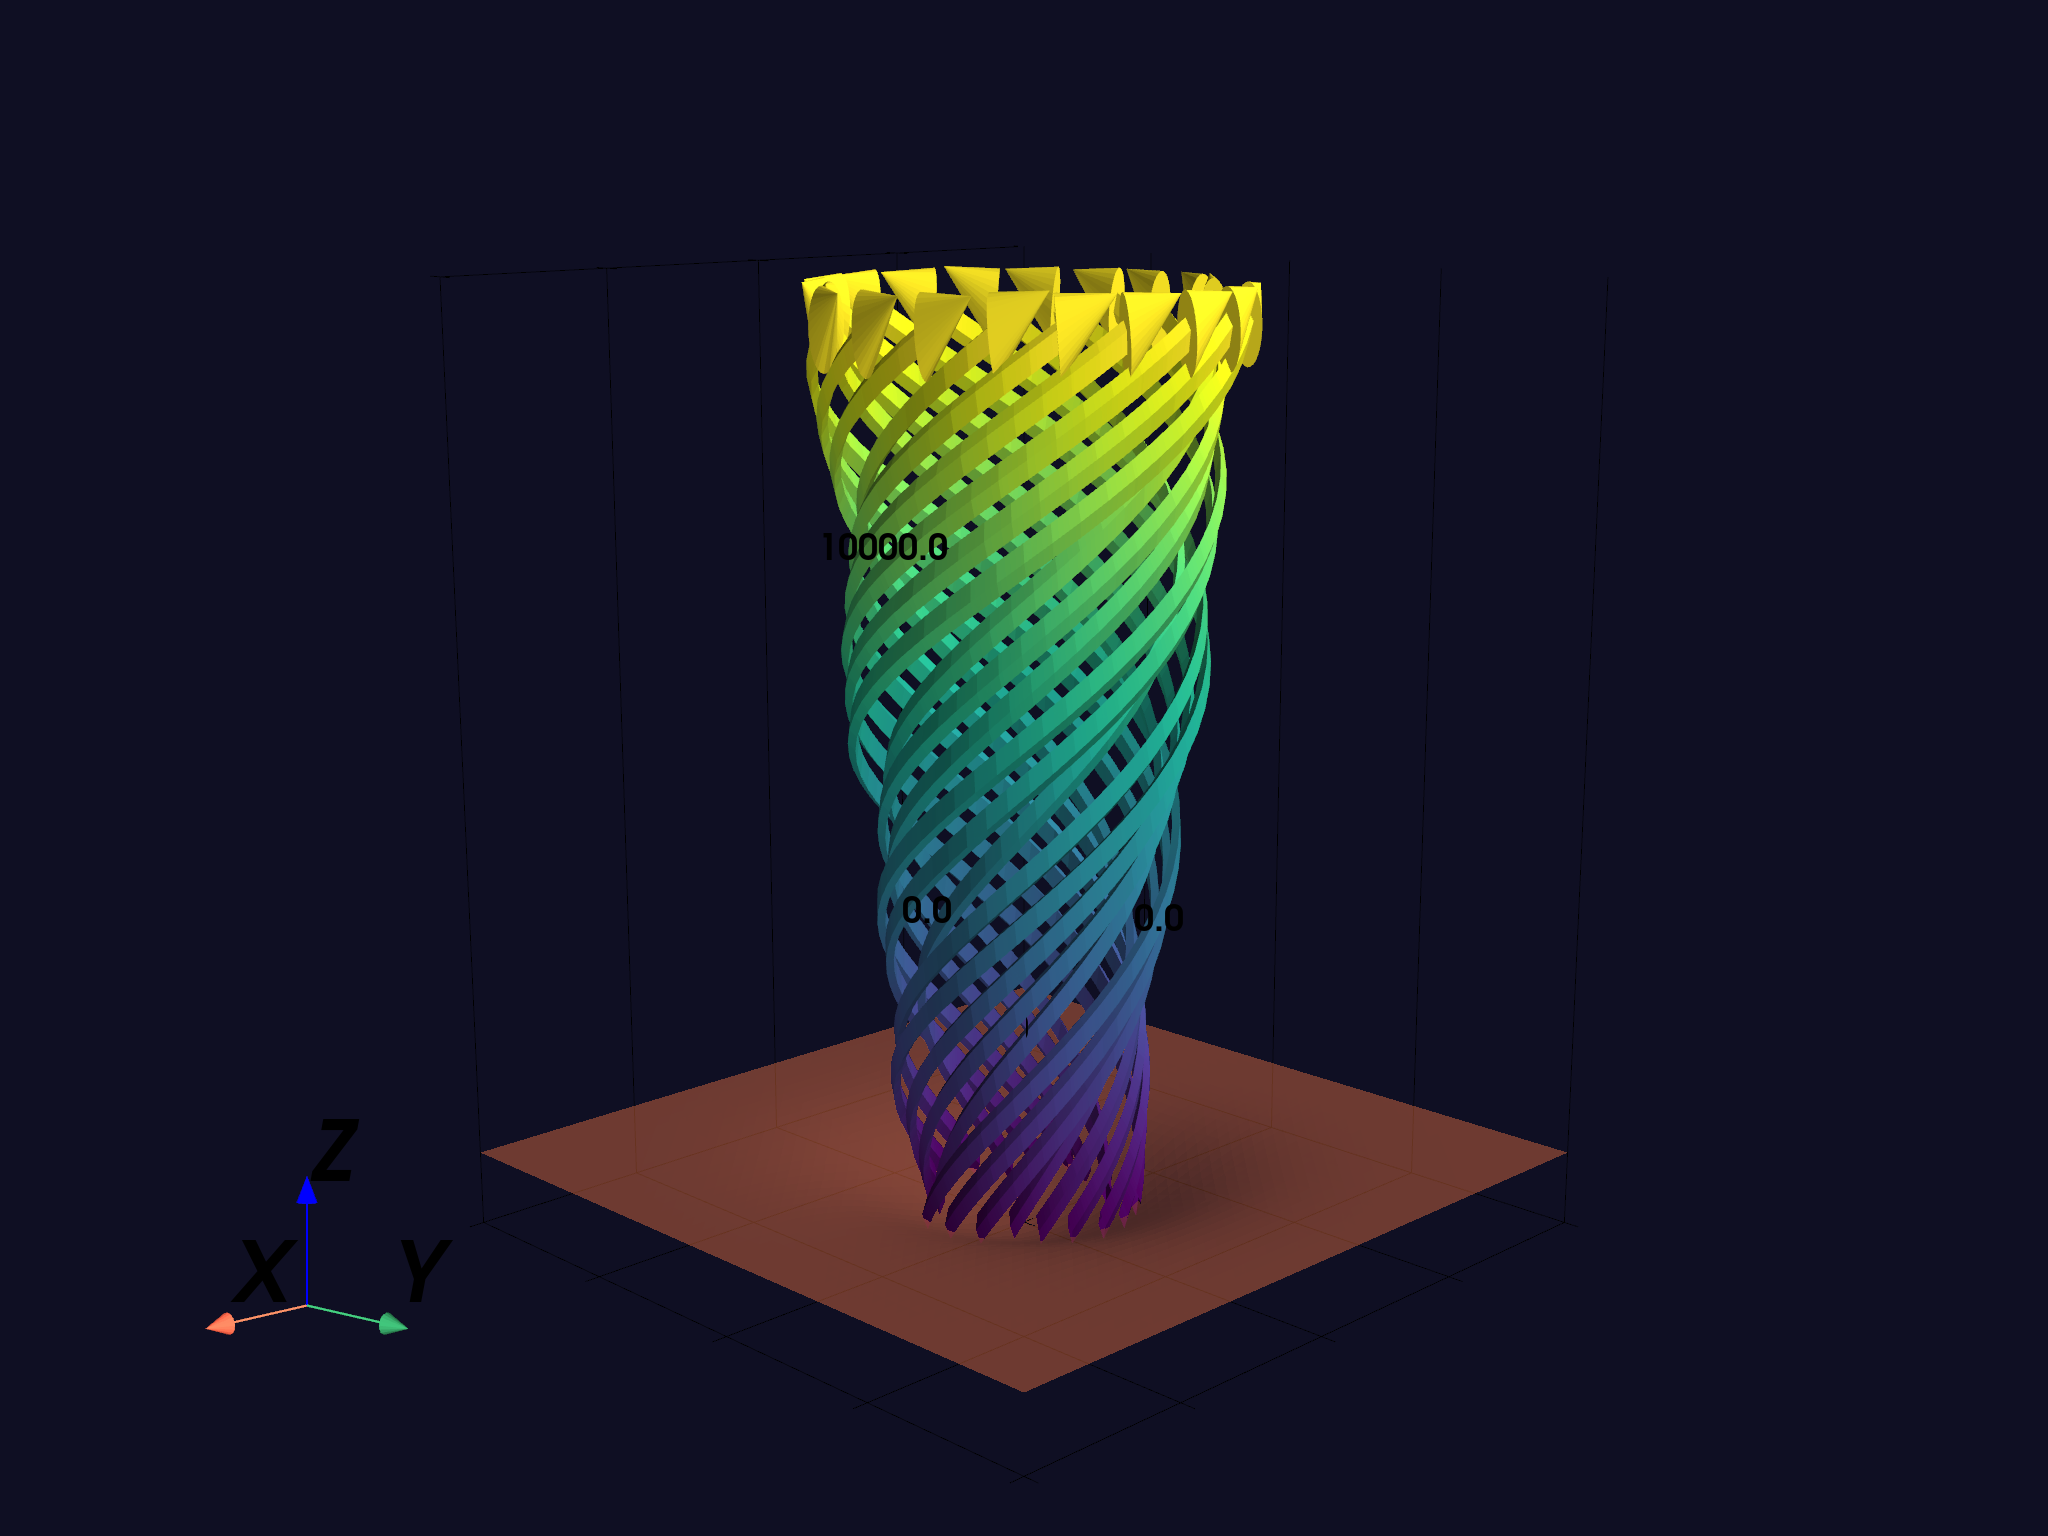

In [7]:
# Create a scene
scene = (
    sv.Scene(background="#0f0f23")
    .add_contour(gridded_ds, "THETA", isosurfaces=[307], opacity=0.5, color="coral")
    .add_trajectories(trajectory_ds, scalar="altitude", cmap="viridis")
)

# Save screenshot to file
screenshot_path = Path("assets/example_screenshot.png")
scene.screenshot(screenshot_path, scale=2)

# Display the saved image
display(Image(filename=screenshot_path))

### Interactive HTML Export

Use `export_html()` to create an interactive 3D viewer that can be opened in any browser or embedded in a notebook.

In [9]:
from IPython.display import IFrame

# Create a scene
scene = (
    sv.Scene(background="black")
    .add_contour(
        gridded_ds, "THETA", isosurfaces=[305, 308], opacity=0.6, cmap="coolwarm"
    )
    .add_slice(gridded_ds, "W", dim="z", value=3000, cmap="RdBu_r")
)

# Export to HTML
html_path = Path("assets/example_interactive.html")
scene.export_html(html_path)
# This won't render correctly within jupyter when read back in,
# but try opening it in your browser

Scene(background='black', title=None, show_grid=True, force_bounds=False, _specs=[(<xarray.Dataset> Size: 3MB
Dimensions:  (x: 50, y: 50, z: 25)
Coordinates:
  * x        (x) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * y        (y) float64 400B 0.0 204.1 408.2 ... 9.592e+03 9.796e+03 1e+04
  * z        (z) float64 200B 0.0 208.3 416.7 ... 4.583e+03 4.792e+03 5e+03
Data variables:
    THETA    (x, y, z) float64 500kB 300.0 302.1 304.2 ... 345.8 347.9 350.0
    W        (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11
    UC       (x, y, z) float64 500kB 10.0 10.0 10.0 10.0 ... 10.0 10.0 10.0 10.0
    VC       (x, y, z) float64 500kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    WC       (x, y, z) float64 500kB 1.378e-13 4.606e-13 ... 4.507e-11 2.046e-11, ContourSpec(name='contour_THETA_iso305', empty_ok=False, grid_type=None, pyvista_create_kwargs={}, pyvista_add_kwargs={}, geometry=ContourGeometry(varname='THETA', isosurfaces=[305, 308], scalar=N

## Best Practices

1. **Start simple**: Use `plot_gridded()` or `plot_trajectories()` first
2. **Use factory functions**: `make_contour()` etc. for custom visualization
3. **Chain methods**: Build complex scenes fluently
4. **Export for sharing**: Use `screenshot()` for static images, `export_html()` for interactive sharing

## Summary

The skyvista API provides three levels of abstraction:

1. **Convenience functions** (`plot_gridded`, `plot_trajectories`) - Quickest way to visualize
2. **Factory functions** (`make_contour`, `make_slice`, etc.) - More control with sensible defaults
3. **Full VarSpec classes** - Maximum control over geometry and appearance